## Name : V.Atchaya
## Reg.no : 212224060031

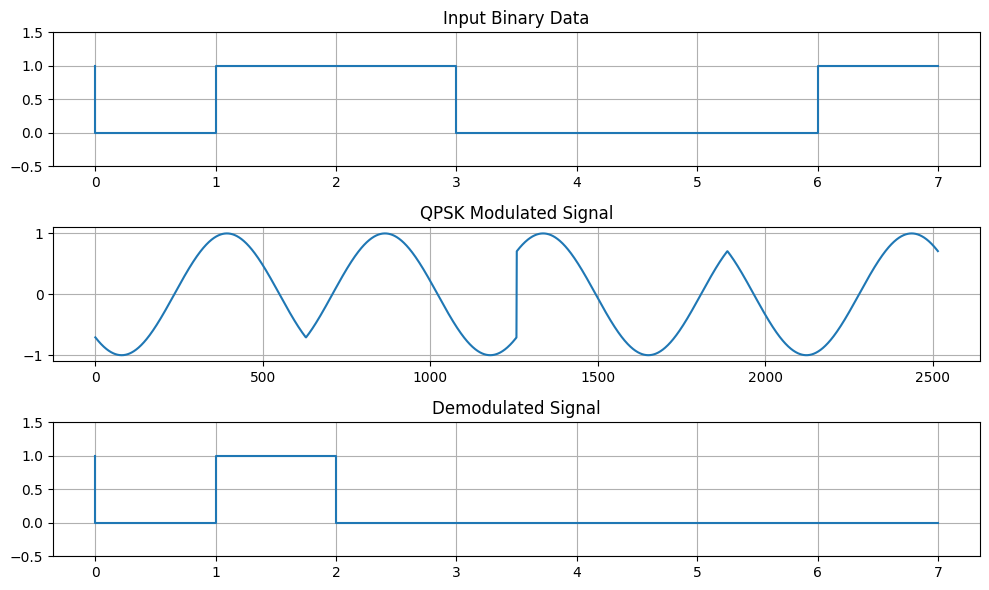

Input Bits: [1, 0, 1, 1, 0, 0, 0, 1]
Decoded Bits: [1, 0, 1, 0, 0, 0, 0, 0]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Input binary data (must be even number of bits)
bits = [1,0, 1,1, 0,0, 0,1]

# Convert bits into bit pairs
symbols = []
for i in range(0, len(bits), 2):
    symbols.append(str(bits[i]) + str(bits[i+1]))

# Time axis
t = np.arange(0, 2*np.pi, 0.01)

# QPSK phase signals
s00 = np.sin(t + np.pi/4)      # 00
s01 = np.sin(t + 3*np.pi/4)    # 01
s10 = np.sin(t + 5*np.pi/4)    # 10
s11 = np.sin(t + 7*np.pi/4)    # 11

# Modulation
modulated_signal = []

for s in symbols:
    if s == "00":
        modulated_signal.extend(s00)
    elif s == "01":
        modulated_signal.extend(s01)
    elif s == "10":
        modulated_signal.extend(s10)
    elif s == "11":
        modulated_signal.extend(s11)

# Demodulation (simple sampling method)
decoded_bits = []
sample_point = int(len(t)/2)

for i in range(len(symbols)):
    sample = modulated_signal[i*len(t) + sample_point]

    if sample > 0.7:
        decoded_bits.extend([1,0])
    elif sample < -0.7:
        decoded_bits.extend([0,0])
    elif sample > 0:
        decoded_bits.extend([0,1])
    else:
        decoded_bits.extend([1,1])

# Plotting
plt.figure(figsize=(10,6))

# Input bits
plt.subplot(3,1,1)
plt.step(range(len(bits)), bits)
plt.title("Input Binary Data")
plt.ylim(-0.5,1.5)
plt.grid(True)

# QPSK Signal
plt.subplot(3,1,2)
plt.plot(modulated_signal)
plt.title("QPSK Modulated Signal")
plt.grid(True)

# Demodulated bits
plt.subplot(3,1,3)
plt.step(range(len(decoded_bits)), decoded_bits)
plt.title("Demodulated Signal")
plt.ylim(-0.5,1.5)
plt.grid(True)

plt.tight_layout()
plt.show()

print("Input Bits:", bits)
print("Decoded Bits:", decoded_bits)